## 🛠️ Exploring Data Imperfection Aspects in a Supply Chain Dataset

<img src="raw_data/DataCo/SupplyChain.jpeg" alt="Smart Supply Chain Dataset (DataCo)" width="500">

In this notebook, we'll load the [Smart Supply Chain Dataset (DataCo)](https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis) and explore various **data imperfection aspects** including:

- **Missing data** 🕳️  
- **Duplicates** 🧑‍🤝‍🧑  
- **Imbalanced data** ⚖️  
- **Bad structure** 🏗️  
- **Inconsistency** ⚡

***
#### 📦 Load the Data

In [1]:
# import pandas as pd

# df = pd.read_csv("raw_data/DataCo/DataCoSupplyChainDataset.csv", encoding="latin1")
# print(f"Shape of data: {df.shape}")
# df.head()

### Load data from a url

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/Dr-AlaaKhamis/ISE518/main/8_Data_imperfection/raw_data/DataCo/DataCoSupplyChainDataset.csv"

df = pd.read_csv(url, encoding="latin1")
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [3]:
df.describe(include='all')

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
count,180524,180524.000000,180524.000000,180524.000000,180524.000000,180524,180524.000000,180524.00000,180524,180524,...,24841.000000,180524.000000,180524.00000,0.0,180524,180524,180524.000000,180524.0,180524,180524
unique,4,NaN,NaN,NaN,NaN,4,NaN,NaN,50,563,...,NaN,NaN,NaN,NaN,118,118,NaN,NaN,63701,4
top,DEBIT,NaN,NaN,NaN,NaN,Late delivery,NaN,NaN,Cleats,Caguas,...,NaN,NaN,NaN,NaN,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,NaN,NaN,4/24/2016 2:18,Standard Class
freq,69296,NaN,NaN,NaN,NaN,98979,NaN,NaN,24551,66772,...,NaN,NaN,NaN,NaN,24515,24515,NaN,NaN,10,107756
mean,NaN,3.497662,2.931859,21.974151,183.108665,NaN,0.548287,31.85146,NaN,NaN,...,55427.002456,692.508642,31.85146,NaN,NaN,NaN,141.233445,0.0,NaN,NaN
std,NaN,1.623722,1.374447,104.434152,120.043061,NaN,0.497664,15.64037,NaN,NaN,...,31918.931215,336.451064,15.64037,NaN,NaN,NaN,139.733106,0.0,NaN,NaN
min,NaN,0.000000,0.000000,-4274.979980,7.490000,NaN,0.000000,2.00000,NaN,NaN,...,1040.000000,19.000000,2.00000,NaN,NaN,NaN,9.990000,0.0,NaN,NaN
25%,NaN,2.000000,2.000000,7.000000,104.379997,NaN,0.000000,18.00000,NaN,NaN,...,23464.000000,403.000000,18.00000,NaN,NaN,NaN,50.000000,0.0,NaN,NaN
50%,NaN,3.000000,4.000000,31.520000,163.990005,NaN,1.000000,29.00000,NaN,NaN,...,59405.000000,627.000000,29.00000,NaN,NaN,NaN,59.990002,0.0,NaN,NaN
75%,NaN,5.000000,4.000000,64.800003,247.399994,NaN,1.000000,45.00000,NaN,NaN,...,90008.000000,1004.000000,45.00000,NaN,NaN,NaN,199.990005,0.0,NaN,NaN


***
### Missing Data

Missing data is a common imperfection. Let's find missing (null/NaN) values in our dataset.

Customer Lname              8
Customer Zipcode            3
Order Zipcode          155683
Product Description    180524
dtype: int64


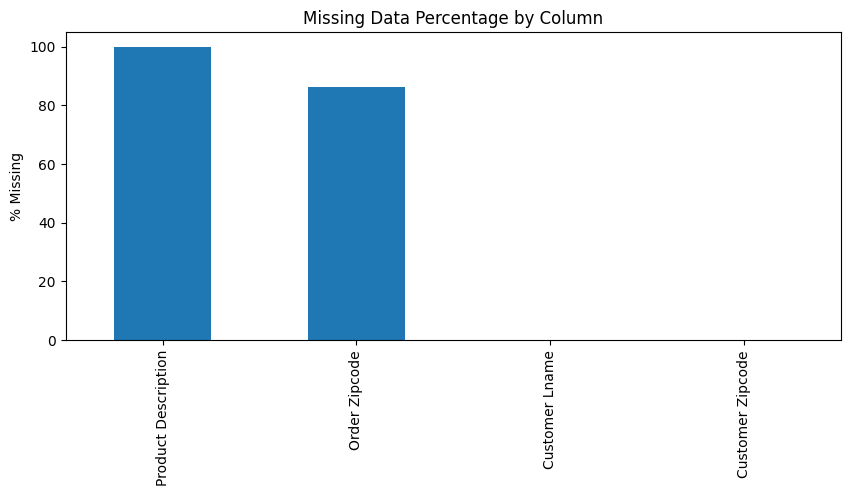

In [4]:
# Show count of missing values for each column
missing_values = df.isnull().sum()
missing_columns = missing_values[missing_values > 0]
print(missing_columns)

# Visualize missing data percentage
import matplotlib.pyplot as plt
missing_percent = 100 * missing_values / len(df)
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
missing_percent.plot(kind='bar', figsize=(10,4), title='Missing Data Percentage by Column')
plt.ylabel('% Missing')
plt.show()

***
### 🧑‍🤝‍🧑 Duplicates

Duplicate rows can skew analysis.  
Let's check for duplicates in the dataset.

In [5]:
# Find number of completely duplicated rows
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

# Show a sample of duplicate rows, if any
df[df.duplicated()].head()

Number of duplicate rows: 5


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
8,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
97,TRANSFER,2,4,51.980000,236.250000,Advance shipping,0,24,Women's Apparel,Caguas,...,NaN,502,24,NaN,http://images.acmesports.sports/Nike+Men%27s+D...,Nike Men's Dri-FIT Victory Golf Polo,50.000000,0,4/15/2017 14:25,Standard Class
186,TRANSFER,5,4,28.850000,128.220001,Shipping canceled,0,13,Electronics,Freeport,...,77041.0,278,13,NaN,http://images.acmesports.sports/Under+Armour+M...,Under Armour Men's Compression EV SL Slide,44.990002,0,5/13/2016 17:42,Standard Class
165582,PAYMENT,2,1,39.209999,112.029999,Late delivery,1,6,Tennis & Racquet,Lancaster,...,NaN,116,6,NaN,http://images.acmesports.sports/Nike+Men%27s+C...,Nike Men's Comfort 2 Slide,44.990002,0,3/30/2016 4:16,First Class
180519,DEBIT,6,4,86.400002,319.980011,Late delivery,1,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/22/2016 6:07,Standard Class


***
### ⚖️ Imbalanced Data

Imbalanced data occurs when some categories are much more frequent than others.  
Let's check for imbalance in key categorical columns (e.g., `Order Status`, `Category Name`, `Customer Country`).

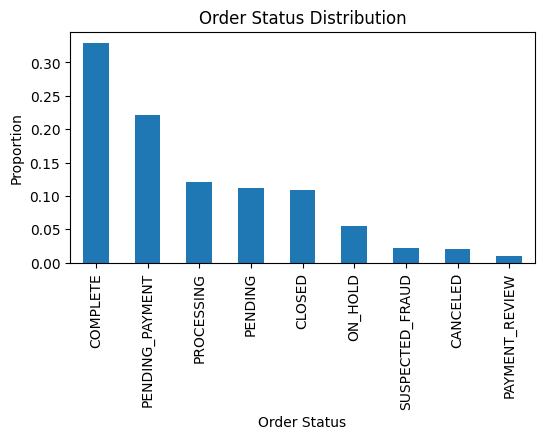

In [6]:
# Example: Order Status imbalance
df['Order Status'].value_counts(normalize=True).plot(
    kind='bar', title='Order Status Distribution', figsize=(6,3))
plt.ylabel('Proportion')
plt.show()

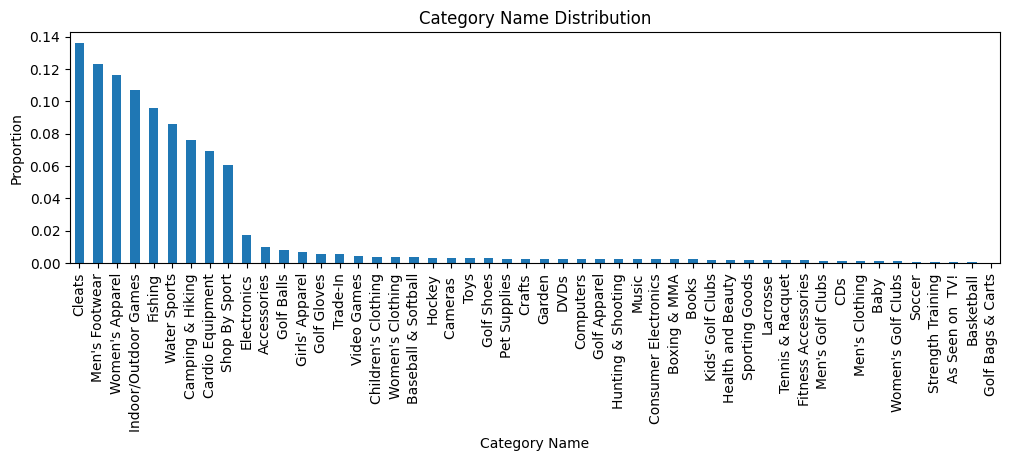

In [7]:
# Example: Category Name imbalance
df['Category Name'].value_counts(normalize=True).plot(
    kind='bar', title='Category Name Distribution', figsize=(12,3))
plt.ylabel('Proportion')
plt.show()

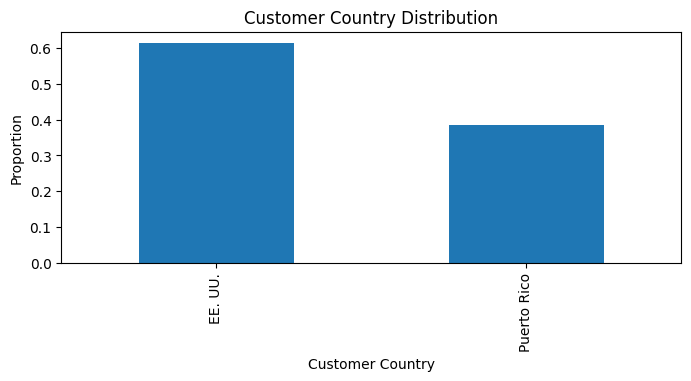

In [8]:
# Example: Customer Country imbalance
df['Customer Country'].value_counts(normalize=True).plot(
    kind='bar', title='Customer Country Distribution', figsize=(8,3))
plt.ylabel('Proportion')
plt.show()

***
### 🏗️ Bad Structure

Bad structure can include strange column names, mixed data types, or misplaced headers.

Let's check for:
- **Suspicious column names**
- **Columns with a single unique value**
- **Columns with many unique values (possible IDs)**
- **Mixed data types**

In [9]:
# Check column names for leading/trailing spaces or weird formatting
print("Column names:", list(df.columns))

# Columns with a single unique value (might not be useful)
single_unique = [col for col in df.columns if df[col].nunique() == 1]
print("Columns with a single unique value:", single_unique)

# Columns with high cardinality (potential IDs)
high_card_cols = [col for col in df.columns if df[col].nunique() > 0.9 * len(df)]
print("Columns with high cardinality (possible IDs):", high_card_cols)

# Columns with mixed data types
for col in df.columns:
    types = df[col].apply(type).nunique()
    if types > 1:
        print(f"Column '{col}' has mixed types.")

Column names: ['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping 

***
### ⚡ Inconsistency

Inconsistencies can occur in categorical values, spelling, case, or units.  
Let's look for inconsistencies in columns like `Order Status`, `Customer Country`, and `Order Region`.

In [10]:
# Show unique values for some key categorical columns to spot inconsistencies
print("Unique Order Status values:", df['Order Status'].unique())
print("Unique Customer Country values:", df['Customer Country'].unique())
print("Unique Order Region values:", df['Order Region'].unique())

Unique Order Status values: ['COMPLETE' 'PENDING' 'CLOSED' 'PENDING_PAYMENT' 'CANCELED' 'PROCESSING'
 'SUSPECTED_FRAUD' 'ON_HOLD' 'PAYMENT_REVIEW']
Unique Customer Country values: ['Puerto Rico' 'EE. UU.']
Unique Order Region values: ['Southeast Asia' 'South Asia' 'Oceania' 'Eastern Asia' 'West Asia'
 'West of USA ' 'US Center ' 'West Africa' 'Central Africa' 'North Africa'
 'Western Europe' 'Northern Europe' 'Central America' 'Caribbean'
 'South America' 'East Africa' 'Southern Europe' 'East of USA' 'Canada'
 'Southern Africa' 'Central Asia' 'Eastern Europe' 'South of  USA ']
